The give code will make the new GRID based data set

Make necessary file names and frequency bands changes for ICE and IMSC. same code works for both set. 

In [5]:
# %%
import numpy as np
import pandas as pd
import datetime 
import logging
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from datetime import timedelta
import os
import pickle
import tqdm 
import geopandas as gpd
from PIL import Image
from matplotlib.patches import Rectangle


In [ ]:
#the cvs file with the cleaned halforbit file names
df1 = pd.read_csv("/storage3/DSIP/Demeter/IMSC/I_IMSC_CleanINPUT_Orbits.csv") # IEC /ICE/I_ICE_CleanINPUT_Orbits


Since we are considering up and down orbits seperptely for our analysis, we make a list of filenames of corresponding orbits alone.


In [ ]:


# %%
nf = []
for filename in df1['UpOrbits']:
    fn = filename
    parts = fn.split('.')
    sp_fn = parts[0] + "_full.pkl" #here i am adding FULL cause, in the format of file name saved in CSV is differnet from the real ASCII file name/.
    nf.append(sp_fn)
 
df1.loc[:, 'sp_filename'] = nf

logging.warning('sp_filename done')
# %%

pickle_folder = "/storage3/DSIP/Demeter/ASCII-IMSC" #ICE /ASCII-ICE

# %%

The fuction for creating grid And providing grid ID

Condition Given for the Grid : 20 degree width

In [12]:


def create_grid(width, depth):

    min_lat, max_lat = -90, 90
    min_lon, max_lon = -180, 180
    
    num_lat_cells = int((max_lat - min_lat) / depth)
    num_lon_cells = int((max_lon - min_lon) / width)

    grid = np.empty((num_lat_cells, num_lon_cells), dtype=object)
    
    # Assign IDs to each grid cell
    for lon_idx in range(num_lon_cells):
        for lat_idx in range(num_lat_cells):
            lat_start = min_lat + lat_idx * depth
            lat_end = lat_start + depth
            lon_start = min_lon + lon_idx * width
            lon_end = lon_start + width
            grid[lat_idx, lon_idx] = f'G{lat_idx * num_lon_cells + lon_idx + 1}: (({lon_start},{lon_end}),({lat_start},{lat_end}))'
            # print(lat_idx,num_lon_cells,lon_idx,lat_idx * num_lon_cells + lon_idx + 1)
            # print(grid[lat_idx, lon_idx])
    return grid

# Example usage
grid = create_grid(20, 20)
# print(grid)


polygon for filtering out the data of desired area

In [7]:



def create_polygon(lat, lon, width):
   
    lat_delta = width / 2
    lon_delta = width / 2
    latitudes = [lat - lat_delta, lat + lat_delta, lat + lat_delta, lat - lat_delta]
    longitudes = [lon - lon_delta, lon - lon_delta, lon + lon_delta, lon + lon_delta]

    
    polygon = Polygon(zip(longitudes, latitudes))

    return polygon


In [8]:


def calculate_average_spectrum(df, width, delta_t, start_time=None):
    df['geoc_lat'] = df['geoc_lat'].astype(float)
    df['geoc_long'] = df['geoc_long'].astype(float)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['geoc_long'] = df['geoc_long'].apply(pd.to_numeric, errors='coerce')
    df['geoc_long'] = df['geoc_long'].apply(lambda x: x - 360 if x > 180 else x)
    result = {}  
    s =[]
    df = df.sort_values(by='datetime')  

    if start_time is None:
        start_time = df.iloc[0]['datetime']

    # Fb for ICE
    bands = [
        (1 * 19.53, 2 * 19.53),
        (15 * 19.53, 19 * 19.53),
        (19 * 19.53, 24 * 19.53),
        (24 * 19.53, 31 * 19.53),
        (31 * 19.53, 39 * 19.53),
        (39 * 19.53, 49 * 19.53),
        (49 * 19.53, 61 * 19.53),
        (61 * 19.53, 77 * 19.53),
        (77 * 19.53, 97 * 19.53),
        (97 * 19.53, 122 * 19.53),
        (122 * 19.53, 154 * 19.53)
    ]

    #fb for IMSC
    # bands = [
    #     (1 * 19.53, 2 * 19.53),
    #     (15 * 19.53, 20 * 19.53),
    #     (20 * 19.53, 25 * 19.53),
    #     (25 * 19.53, 32 * 19.53),
    #     (32 * 19.53, 40 * 19.53),
    #     (40 * 19.53, 51 * 19.53)
    # ]
    min_freq = 19.53
    max_freq = 20000
   
    while start_time:
        t = start_time  

        
        row_with_start_time = df[df['datetime'] == start_time]

        if not row_with_start_time.empty:
            lat = row_with_start_time.iloc[0]['geoc_lat']
            lon = row_with_start_time.iloc[0]['geoc_long']

            polygon = create_polygon(lat, lon, width)

            fdf = df[df.apply(lambda x: Point(x['geoc_long'], x['geoc_lat']).within(polygon), axis=1)]

            if not fdf.empty:
                sp0 = np.array([np.array(x) for x in fdf['spectrum0']]).astype(float)
                sp1 = np.array([np.array(x) for x in fdf['spectrum1']]).astype(float)
                sp = np.empty((sp0.shape[0], sp0.shape[1]*2))
                for i in range(sp0.shape[0]):
                    sp[i] = np.concatenate((sp0[i], sp1[i]))
                sp = sp.reshape((sp0.shape[0]*2, 1024))

                for band_id, band in enumerate(bands,1):
                    min_freq_band, max_freq_band = band

                    start_index = int(min_freq_band / (max_freq / 1024))
                    end_index = int(max_freq_band / (max_freq / 1024))
                    
                    sp_range = sp[:, start_index:end_index].flatten()
                    # print(len(sp_range))
                    

                    Q1 = np.percentile(sp_range, 25)
                    Q2 = np.percentile(sp_range, 50)                     
                    Q3 = np.percentile(sp_range, 75)
                    P12_5 = np.percentile(sp_range, 12.5)
                    P87_5 = np.percentile(sp_range, 87.5)
                    maximum = max(sp_range)
                    
                    # Filter the data to include only the central 75%
                    # Q75 = sp_range[(sp_range > P12_5) & (sp_range < P87_5)]
                    # print(len(Q75))

                    grid = create_grid(20, 20).reshape(-1)
                
                    best_grid_id = None
                    max_intersection = 0

                   
                    for g_id, g in enumerate(grid,1):
                        full_grid_id = f'G{g_id}'
                        
                        lon_range, lat_range = g.split(': ((')[1].strip(')').split('),(')
                        lon_start, lon_end = map(float, lon_range.split(','))
                        lat_start, lat_end = map(float, (lat_range.split(',')))

                       
                        grid_polygon = Polygon([(lon_start, lat_start), (lon_start, lat_end), (lon_end, lat_end), (lon_end, lat_start)])

                        
                        polygon_area = polygon.area
                        intersection_area = grid_polygon.intersection(polygon).area
                        percent_intersection = (intersection_area / polygon_area) * 100

                        
                        if percent_intersection > max_intersection:
                            max_intersection = percent_intersection
                            best_grid_id = full_grid_id
                    #         print(best_grid_id, max_intersection)
                    # print('the best grid ',best_grid_id )
                    if best_grid_id is not None:
                        if best_grid_id not in result:
                            result[best_grid_id] = []
                        # Store statistics for the current band in the result dictionary
                        result[best_grid_id].append({
                            f"fb_{band_id}": {'datetime': t,
                                                     'max': maximum,
                                                     'Q1':Q1,
                                                     'Q2':Q2,
                                                     'Q3': Q3,
                                                     'lat':lat,
                                                     'lon':lon
                                    
                                                        }
                        })

        
        next_time = start_time + timedelta(minutes=delta_t)
        next_time_row = df[df['datetime'] >= next_time]
        if not next_time_row.empty:
            # Update start_time
            start_time = next_time_row.iloc[0]['datetime']
        else:
           
            break

    return result
#%%


Condition Given for the Grid : 20 degree width

Condition for polygon : 10 degree width

condition calculation fo features : every 2 mins.

In [ ]:

logging.warning('moving to the loop of fn')
# %%
aggregate_result_dict = {}

# Iterate through each pickle file
for file in tqdm.tqdm(df1['sp_filename']):
    # Load DataFrame from pickle file
    df = pd.read_pickle(os.path.join(pickle_folder, file))

    # Apply calculate_average_spectrum function
    result = calculate_average_spectrum(df, 10, 2, start_time=None)

    # Merge result with aggregate_result_dict
    for key, value in result.items():
        if key not in aggregate_result_dict:
            aggregate_result_dict[key] = []
        aggregate_result_dict[key].extend(value)


with open("/storage3/DSIP/Demeter/Newdataset/Up_Orbits-max-val-location_IMSC.pkl", "wb") as f:
    pickle.dump(aggregate_result_dict, f)


print("Aggregated results saved to PKL FILE")

# %%





Check with single half orbit - 1132 means ICE

In [13]:
fn="1132_027640_20050108_120037_20050108_123753_full.pkl"
df = pd.read_pickle(f"D:\\ASCII-ICE\\{fn}")
orbit = fn.split('_')[1]

In [14]:
result = calculate_average_spectrum(df, 10, 2, start_time=None)


In [15]:
result.keys()

dict_keys(['G135', 'G117', 'G116', 'G98', 'G80', 'G62', 'G44', 'G43', 'G25', 'G6'])

Visualising the Keys 

In [16]:


def create_grid(width, depth):
    min_lat, max_lat = -90, 90
    min_lon, max_lon = -180, 180
    
    num_lat_cells = int((max_lat - min_lat) / depth)
    num_lon_cells = int((max_lon - min_lon) / width)
    # print(num_lon_cells)
    # Create an empty grid to store the IDs
    grid = np.empty((num_lat_cells, num_lon_cells), dtype=object)
    
    # Assign IDs to each grid cell
    for lon_idx in range(num_lon_cells):
        for lat_idx in range(num_lat_cells):
            lat_start = min_lat + lat_idx * depth
            lat_end = lat_start + depth
            lon_start = min_lon + lon_idx * width
            lon_end = lon_start + width
            # grid[lat_idx, lon_idx] = f'G{lat_idx * num_lon_cells + lon_idx + 1}: (({lon_start},{lon_end}),({lat_start},{lat_end}))'
            grid[lat_idx, lon_idx] = f'G{lat_idx * num_lon_cells + lon_idx + 1}'
    
    return grid

# Example usage
grid = create_grid(20, 20)
print(grid)


[['G1' 'G2' 'G3' 'G4' 'G5' 'G6' 'G7' 'G8' 'G9' 'G10' 'G11' 'G12' 'G13'
  'G14' 'G15' 'G16' 'G17' 'G18']
 ['G19' 'G20' 'G21' 'G22' 'G23' 'G24' 'G25' 'G26' 'G27' 'G28' 'G29' 'G30'
  'G31' 'G32' 'G33' 'G34' 'G35' 'G36']
 ['G37' 'G38' 'G39' 'G40' 'G41' 'G42' 'G43' 'G44' 'G45' 'G46' 'G47' 'G48'
  'G49' 'G50' 'G51' 'G52' 'G53' 'G54']
 ['G55' 'G56' 'G57' 'G58' 'G59' 'G60' 'G61' 'G62' 'G63' 'G64' 'G65' 'G66'
  'G67' 'G68' 'G69' 'G70' 'G71' 'G72']
 ['G73' 'G74' 'G75' 'G76' 'G77' 'G78' 'G79' 'G80' 'G81' 'G82' 'G83' 'G84'
  'G85' 'G86' 'G87' 'G88' 'G89' 'G90']
 ['G91' 'G92' 'G93' 'G94' 'G95' 'G96' 'G97' 'G98' 'G99' 'G100' 'G101'
  'G102' 'G103' 'G104' 'G105' 'G106' 'G107' 'G108']
 ['G109' 'G110' 'G111' 'G112' 'G113' 'G114' 'G115' 'G116' 'G117' 'G118'
  'G119' 'G120' 'G121' 'G122' 'G123' 'G124' 'G125' 'G126']
 ['G127' 'G128' 'G129' 'G130' 'G131' 'G132' 'G133' 'G134' 'G135' 'G136'
  'G137' 'G138' 'G139' 'G140' 'G141' 'G142' 'G143' 'G144']
 ['G145' 'G146' 'G147' 'G148' 'G149' 'G150' 'G151' 'G152' 'G

In [17]:

coordinate_list = list(zip(df['geoc_long'][::30], df['geoc_lat'][::30])) # since checking for every 2 mins data points


for i, (lon, lat) in enumerate(coordinate_list):
    lon = float(lon)
    # Correcting the longitude value if it's greater than 180
    lon = int(lon) - 360 if lon > 180 else lon
    # Update the tuple in the list with the corrected longitude
    coordinate_list[i] = (lon, lat)


C:\Users\mbabu\AppData\Local\Temp\ipykernel_63244\3279617937.py:22: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


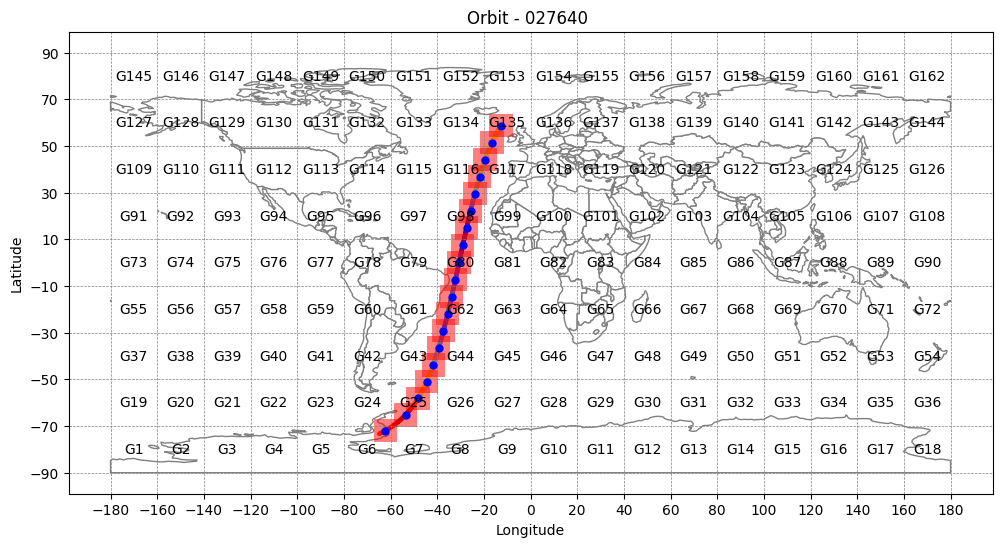

In [18]:


def plot_grid_with_ids_and_coordinates(grid, width, depth, all_data, coordinates_list,orbit):
    latitude = all_data['geoc_lat']
    longitude = all_data['geoc_long']
    spectrum_values = all_data['spectrum0'].values
    sp_01 = np.array([np.array(x) for x in spectrum_values])
    sp_01 = sp_01.astype(float)

    freq_list = np.linspace(19, 20000,)
    freq_of_interest = 19800
    freq_diff = np.abs(freq_list - freq_of_interest)
    freq_index = np.argmin(freq_diff)
    power_spectrum_at_freq = sp_01[:, freq_index]

    # Create a GeoDataFrame with latitude and longitude coordinates
    all_data['geo_long'] = all_data['geoc_long'].apply(pd.to_numeric, errors='coerce')
    all_data['geom_long'] = all_data['geo_long'].apply(lambda x: x - 360 if x > 180 else x)
    gdf = gpd.GeoDataFrame(all_data, geometry=gpd.points_from_xy(all_data['geom_long'], all_data.geoc_lat))

    # Plot all orbits on a single world map using Geopandas and Matplotlib
    fig, ax = plt.subplots(figsize=(24, 6))
    cmap = 'jet'
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world.plot(ax=ax, color='white', edgecolor='grey', zorder=1)
    scatter = gdf.plot(column=sp_01[:, freq_index], cmap=cmap, markersize=5, ax=ax)

    # Plot latitude lines
    for lat in np.arange(-90, 91, depth):
        ax.axhline(y=lat, color='gray', linestyle='--', linewidth=0.5)

    # Plot longitude lines
    for lon in np.arange(0, 361, width):  # Adjusted range to match grid calculation
        ax.axvline(x=lon - 180, color='gray', linestyle='--', linewidth=0.5)  # Adjusted longitude

    # Plot grid IDs
    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            lat_start = -90 + lat_idx * depth
            lon_start = lon_idx * width

            # Add grid ID text
            ax.text(lon_start + width / 2 - 180, lat_start + depth / 2, grid[lat_idx, lon_idx], ha='center', va='center')  # Adjusted longitude

    # Plot the coordinates from the list
    for coord in coordinates_list:


        ax.plot(float(coord[0]), float(coord[1]), marker='o', color='blue', markersize=5)

    for coord in coordinates_list:
        center_point = (float(coord[1]), float(coord[0]))
        half_width = 5
        square_polygon = Polygon([(center_point[1] - half_width, center_point[0] - half_width),
                                (center_point[1] + half_width, center_point[0] - half_width),
                                (center_point[1] + half_width, center_point[0] + half_width),
                                (center_point[1] - half_width, center_point[0] + half_width)])

    # Plot the polygon
        patch = gpd.GeoSeries([square_polygon]).plot(ax=ax, color='red', alpha=0.5)

    # Set x and y label frequency
    ax.set_xticks(np.arange(-180, 181, 20))
    ax.set_yticks(np.arange(-90, 91, 20))

    # Set title
    ax.set_title(f'Orbit - {orbit} ')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    # plt.savefig('high_dpi_plot.png', dpi=300, bbox_inches='tight')
    # Show plot
    plt.show()
    # plt.savefig('high_dpi_plot.png', dpi=300, bbox_inches='tight')


# Plot grid with IDs on world map along with additional coordinates
plot_grid_with_ids_and_coordinates(grid, 20, 20, df, coordinate_list,orbit)
